## Model A: Baseline Accounting Determinants of Capital Structure

## National Company Data Query (based on WRDS)¶

In [1]:
pip install wrds pandas pyarrow psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [3]:
import wrds
conn = wrds.Connection()  # The WRDS username and password 

Enter your WRDS username [zshen]: sxz960
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\zshen\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
preview = conn.raw_sql("""
    select gvkey, conm, sic, fic, costat
    from comp.company
    where fic = 'USA'
    order by gvkey
    limit 5;
""")
preview

,gvkey,conm,sic,fic,costat
0,001000,A & E PLASTIK PAK INC,3089,USA,I
1,001001,A & M FOOD SERVICES INC,5812,USA,I
2,001002,AAI CORP,3825,USA,I
3,001003,A.A. IMPORTING CO INC,5712,USA,I
4,001004,AAR CORP,5080,USA,A


In [5]:
cols_check = conn.raw_sql("select * from comp.company limit 5;")
cols_check.columns.tolist()

['conm',
 'gvkey',
 'add1',
 'add2',
 'add3',
 'add4',
 'addzip',
 'busdesc',
 'cik',
 'city',
 'conml',
 'costat',
 'county',
 'dlrsn',
 'ein',
 'fax',
 'fic',
 'fyrc',
 'ggroup',
 'gind',
 'gsector',
 'gsubind',
 'idbflag',
 'incorp',
 'loc',
 'naics',
 'phone',
 'prican',
 'prirow',
 'priusa',
 'sic',
 'spcindcd',
 'spcseccd',
 'spcsrc',
 'state',
 'stko',
 'weburl',
 'dldte',
 'ipodate',
 'curr_sp500_flag']

In [6]:
# comp.security
sec_cols = conn.raw_sql("select * from comp.security limit 5;")
sec_cols.columns.tolist()

['tic',
 'gvkey',
 'iid',
 'cusip',
 'dlrsni',
 'dsci',
 'epf',
 'exchg',
 'excntry',
 'ibtic',
 'isin',
 'secstat',
 'sedol',
 'tpci',
 'dldtei',
 'curr_sp500_flag']

In [7]:
skeleton = conn.raw_sql("""
    select c.gvkey, c.conm, c.fic, c.sic, c.costat,
           s.tic, s.exchg, s.cusip
    from comp.company as c
    left join comp.security as s
        on c.gvkey = s.gvkey
    where c.fic = 'USA'
    order by c.gvkey
    limit 10;
""")
skeleton

,gvkey,conm,fic,sic,costat,tic,exchg,cusip
0,001000,A & E PLASTIK PAK INC,USA,3089,I,AE.2,12,000032102
1,001001,A & M FOOD SERVICES INC,USA,5812,I,AMFD.,14,000165100
2,001002,AAI CORP,USA,3825,I,AAIC.1,13,000352104
3,001003,A.A. IMPORTING CO INC,USA,5712,I,ANTQ,19,000354100
4,001004,AAR CORP,USA,5080,A,AIR,11,000361105
5,001005,A.B.A. INDUSTRIES INC,USA,3724,I,ABA.2,12,000370106
6,001006,ABC INDS INC,USA,2711,I,1145B,1,000736108
7,001007,ABKCO INDUSTRIES INC,USA,3652,I,4135B,1,000774109
8,001008,ABM COMPUTER SYSTEMS INC,USA,3577,I,ABMC.,13,000775106
9,001009,ABS INDUSTRIES INC,USA,3460,I,ABSI.1,19,000781104


In [8]:
# 1) Basic Information of American Companies（company）
company_basic = conn.raw_sql("""
    SELECT gvkey, conm, fic, sic, costat
    FROM comp.company
    WHERE fic = 'USA'
""")

# 2) security：iid='01'
sec_primary = conn.raw_sql("""
    SELECT gvkey, iid, tic, exchg, cusip
    FROM comp.security
    WHERE iid = '01'
""")

# 3) Merge: One company per row (there may still be a few GVKEYs where security does not have 'iid = "01"', and the tic will be empty)
master = (company_basic
          .merge(sec_primary, on='gvkey', how='left')
          .drop_duplicates()
          .reset_index(drop=True))

print("Number of companies(gvkey)：", master['gvkey'].nunique(), "| column number：", len(master))
master.head(10)

Number of companies(gvkey)： 41422 | column number： 41422


,gvkey,conm,fic,sic,costat,iid,tic,exchg,cusip
0,001000,A & E PLASTIK PAK INC,USA,3089,I,01,AE.2,12,000032102
1,001001,A & M FOOD SERVICES INC,USA,5812,I,01,AMFD.,14,000165100
2,001002,AAI CORP,USA,3825,I,01,AAIC.1,13,000352104
3,001003,A.A. IMPORTING CO INC,USA,5712,I,01,ANTQ,19,000354100
4,001004,AAR CORP,USA,5080,A,01,AIR,11,000361105
5,001005,A.B.A. INDUSTRIES INC,USA,3724,I,01,ABA.2,12,000370106
6,001006,ABC INDS INC,USA,2711,I,01,1145B,1,000736108
7,001007,ABKCO INDUSTRIES INC,USA,3652,I,01,4135B,1,000774109
8,001008,ABM COMPUTER SYSTEMS INC,USA,3577,I,01,ABMC.,13,000775106
9,001009,ABS INDUSTRIES INC,USA,3460,I,01,ABSI.1,19,000781104


In [9]:
funda_preview = conn.raw_sql("""
    SELECT gvkey, datadate, fyear, fyr, at, lt, sale, ebitda, ppent, dp, che, dvc, ni, dltt, dlc
    FROM comp.funda
    WHERE fic = 'USA'
      AND indfmt = 'INDL'
      AND datafmt = 'STD'
      AND consol = 'C'
      AND datadate BETWEEN '2000-01-01' AND '2025-12-31'
    LIMIT 20;
""")
funda_preview.head()

,gvkey,datadate,fyear,fyr,at,lt,sale,ebitda,ppent,dp,che,dvc,ni,dltt,dlc
0,001004,2000-05-31,1999,5,740.998,401.483,1024.333,89.031,110.003,18.373,1.241,9.218,35.163,180.447,26.314
1,001004,2001-05-31,2000,5,701.854,361.642,874.255,64.367,108.907,18.577,13.809,9.157,18.531,179.987,13.652
2,001004,2002-05-31,2001,5,710.199,399.964,638.721,27.207,102.591,22.496,34.522,4.43,-58.939,217.699,42.525
3,001004,2003-05-31,2002,5,686.621,391.633,606.337,30.745,166.761,27.172,29.154,0.797,-12.41,164.658,92.256
4,001004,2004-05-31,2003,5,709.292,407.608,651.958,47.491,166.137,26.68,41.01,0.0,3.504,248.666,3.392


In [10]:
# 2000–2005 as an example
funda_0005 = conn.raw_sql("""
    SELECT gvkey, datadate, fyear, fyr, at, lt, sale, ebitda, ppent, dp, che, dvc, ni, dltt, dlc
    FROM comp.funda
    WHERE fic = 'USA'
      AND indfmt = 'INDL'
      AND datafmt = 'STD'
      AND consol = 'C'
      AND datadate BETWEEN '2000-01-01' AND '2005-12-31'
""")
print(len(funda_0005))
funda_0005.head()

53995


,gvkey,datadate,fyear,fyr,at,lt,sale,ebitda,ppent,dp,che,dvc,ni,dltt,dlc
0,001004,2000-05-31,1999,5,740.998,401.483,1024.333,89.031,110.003,18.373,1.241,9.218,35.163,180.447,26.314
1,001004,2001-05-31,2000,5,701.854,361.642,874.255,64.367,108.907,18.577,13.809,9.157,18.531,179.987,13.652
2,001004,2002-05-31,2001,5,710.199,399.964,638.721,27.207,102.591,22.496,34.522,4.43,-58.939,217.699,42.525
3,001004,2003-05-31,2002,5,686.621,391.633,606.337,30.745,166.761,27.172,29.154,0.797,-12.41,164.658,92.256
4,001004,2004-05-31,2003,5,709.292,407.608,651.958,47.491,166.137,26.68,41.01,0.0,3.504,248.666,3.392


In [11]:
cols_master = ['gvkey','conm','fic','sic','costat','tic','exchg','cusip']
panel_0005 = (funda_0005
              .merge(master[cols_master], on='gvkey', how='left')
              .drop_duplicates()
              .reset_index(drop=True))

print("table rows' number：", len(panel_0005), 
      " | Number of companies：", panel_0005['gvkey'].nunique())
panel_0005.head()

table rows' number： 53995  | Number of companies： 12005


,gvkey,datadate,fyear,fyr,at,lt,sale,ebitda,ppent,dp,...,ni,dltt,dlc,conm,fic,sic,costat,tic,exchg,cusip
0,001004,2000-05-31,1999,5,740.998,401.483,1024.333,89.031,110.003,18.373,...,35.163,180.447,26.314,AAR CORP,USA,5080,A,AIR,11,000361105
1,001004,2001-05-31,2000,5,701.854,361.642,874.255,64.367,108.907,18.577,...,18.531,179.987,13.652,AAR CORP,USA,5080,A,AIR,11,000361105
2,001004,2002-05-31,2001,5,710.199,399.964,638.721,27.207,102.591,22.496,...,-58.939,217.699,42.525,AAR CORP,USA,5080,A,AIR,11,000361105
3,001004,2003-05-31,2002,5,686.621,391.633,606.337,30.745,166.761,27.172,...,-12.41,164.658,92.256,AAR CORP,USA,5080,A,AIR,11,000361105
4,001004,2004-05-31,2003,5,709.292,407.608,651.958,47.491,166.137,26.68,...,3.504,248.666,3.392,AAR CORP,USA,5080,A,AIR,11,000361105


In [12]:
ordered = ['gvkey','conm','tic','exchg','cusip','fic','sic','costat',
           'fyear','fyr','datadate','at','lt','sale','ebitda','ppent', 'dp', 'che', 'dvc', 'ni', 'dltt', 'dlc']
panel_0005 = panel_0005[ordered]

panel_0005.to_csv("panel_USA_2000_2005.csv", index=False)
print("Saved: panel_USA_2000_2005.csv")
panel_0005.head(10)

Saved: panel_USA_2000_2005.csv


,gvkey,conm,tic,exchg,cusip,fic,sic,costat,fyear,fyr,...,lt,sale,ebitda,ppent,dp,che,dvc,ni,dltt,dlc
0,001004,AAR CORP,AIR,11,000361105,USA,5080,A,1999,5,...,401.483,1024.333,89.031,110.003,18.373,1.241,9.218,35.163,180.447,26.314
1,001004,AAR CORP,AIR,11,000361105,USA,5080,A,2000,5,...,361.642,874.255,64.367,108.907,18.577,13.809,9.157,18.531,179.987,13.652
2,001004,AAR CORP,AIR,11,000361105,USA,5080,A,2001,5,...,399.964,638.721,27.207,102.591,22.496,34.522,4.43,-58.939,217.699,42.525
3,001004,AAR CORP,AIR,11,000361105,USA,5080,A,2002,5,...,391.633,606.337,30.745,166.761,27.172,29.154,0.797,-12.41,164.658,92.256
4,001004,AAR CORP,AIR,11,000361105,USA,5080,A,2003,5,...,407.608,651.958,47.491,166.137,26.68,41.01,0.0,3.504,248.666,3.392
5,001004,AAR CORP,AIR,11,000361105,USA,5080,A,2004,5,...,417.486,747.848,61.774,139.137,27.95,50.338,0.0,15.453,227.159,3.745
6,001010,ACF INDUSTRIES INC,4165A,0,00099V004,USA,3743,I,2000,12,...,2794.5,443.8,178.7,1453.3,61.7,113.0,0.0,79.9,1866.8,176.1
7,001010,ACF INDUSTRIES INC,4165A,0,00099V004,USA,3743,I,2001,12,...,2694.5,366.5,179.6,1532.8,69.4,145.5,<NA>,145.7,1788.5,117.0
8,001010,ACF INDUSTRIES INC,4165A,0,00099V004,USA,3743,I,2002,12,...,2735.1,313.3,162.0,1574.1,73.4,24.8,<NA>,79.7,1771.7,197.0
9,001010,ACF INDUSTRIES INC,4165A,0,00099V004,USA,3743,I,2003,12,...,3084.3,2339.1,161.5,2237.4,223.4,698.7,0.1,352.5,1674.7,185.4


In [13]:
import os
os.makedirs("out/funda_panel", exist_ok=True)

def fetch_funda_year(year):
    sql = f"""
        SELECT gvkey, datadate, fyear, fyr, at, lt, sale, ebitda, ppent, dp, che, dvc, ni, dltt, dlc
        FROM comp.funda
        WHERE fic = 'USA'
          AND indfmt = 'INDL'
          AND datafmt = 'STD'
          AND consol = 'C'
          AND fyear = {year}
    """
    dfy = conn.raw_sql(sql)
    
    cols_master = ['gvkey','conm','fic','sic','costat','tic','exchg','cusip']
    panel_y = (master[cols_master].merge(dfy, on='gvkey', how='left')
                              .drop_duplicates()
                              .reset_index(drop=True))
    
    ordered = ['gvkey','conm','tic','exchg','cusip','fic','sic','costat',
               'fyear','fyr','datadate','at','lt','sale','ebitda','ppent','dp','che','dvc','ni','dltt','dlc']
    panel_y = panel_y.reindex(columns=ordered)
    
    out_path = f"out/funda_panel/panel_USA_{year}.parquet"
    panel_y.to_parquet(out_path, index=False)
    print(year, len(panel_y), "rows ->", out_path)
    return out_path

In [14]:
for yr in range(2000, 2025):   # The annual report is currently updated up to 2024.
    _ = fetch_funda_year(yr)

2000 41422 rows -> out/funda_panel/panel_USA_2000.parquet
2001 41422 rows -> out/funda_panel/panel_USA_2001.parquet
2002 41422 rows -> out/funda_panel/panel_USA_2002.parquet
2003 41422 rows -> out/funda_panel/panel_USA_2003.parquet
2004 41422 rows -> out/funda_panel/panel_USA_2004.parquet
2005 41422 rows -> out/funda_panel/panel_USA_2005.parquet
2006 41422 rows -> out/funda_panel/panel_USA_2006.parquet
2007 41422 rows -> out/funda_panel/panel_USA_2007.parquet
2008 41422 rows -> out/funda_panel/panel_USA_2008.parquet
2009 41422 rows -> out/funda_panel/panel_USA_2009.parquet
2010 41423 rows -> out/funda_panel/panel_USA_2010.parquet
2011 41423 rows -> out/funda_panel/panel_USA_2011.parquet
2012 41423 rows -> out/funda_panel/panel_USA_2012.parquet
2013 41423 rows -> out/funda_panel/panel_USA_2013.parquet
2014 41423 rows -> out/funda_panel/panel_USA_2014.parquet
2015 41423 rows -> out/funda_panel/panel_USA_2015.parquet
2016 41423 rows -> out/funda_panel/panel_USA_2016.parquet
2017 41423 row

In [15]:
import pandas as pd

df2000 = pd.read_parquet("out/funda_panel/panel_USA_2000.parquet") #Select 2000 parts of the data to check if all have been extracted completely
print("column number:", len(df2000.columns))
print("column name:")
print(df2000.columns.tolist())

column number: 22
column name:
['gvkey', 'conm', 'tic', 'exchg', 'cusip', 'fic', 'sic', 'costat', 'fyear', 'fyr', 'datadate', 'at', 'lt', 'sale', 'ebitda', 'ppent', 'dp', 'che', 'dvc', 'ni', 'dltt', 'dlc']


In [16]:
df2000.head() #lots of missing value

,gvkey,conm,tic,exchg,cusip,fic,sic,costat,fyear,fyr,...,lt,sale,ebitda,ppent,dp,che,dvc,ni,dltt,dlc
0,001000,A & E PLASTIK PAK INC,AE.2,12,000032102,USA,3089,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,001001,A & M FOOD SERVICES INC,AMFD.,14,000165100,USA,5812,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,001002,AAI CORP,AAIC.1,13,000352104,USA,3825,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,001003,A.A. IMPORTING CO INC,ANTQ,19,000354100,USA,5712,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,001004,AAR CORP,AIR,11,000361105,USA,5080,A,2000,5,...,361.642,874.255,64.367,108.907,18.577,13.809,9.157,18.531,179.987,13.652


## Calculate Accounting Variables

In [17]:
#First, calculate the static accounting variables for each year separately.
import pandas as pd
import numpy as np

In [18]:
#datasets: 2000, take the first year as an example
df2000 = pd.read_parquet("out/funda_panel/panel_USA_2000.parquet")

df2000["log_assets"] = np.log(df2000["at"])
df2000["ebitda_margin"] = df2000["ebitda"] / df2000["sale"]
df2000["asset_tangibility"] = df2000["ppent"] / df2000["at"]
df2000["cash_holdings"] = df2000["che"] / df2000["at"]
df2000["non_debt_tax_shield"] = df2000["dp"] / df2000["at"]
df2000["roa"] = df2000["ni"] / df2000["at"]
df2000["book_leverage"] = (df2000["dltt"].fillna(0) + df2000["dlc"].fillna(0)) / df2000["at"]
# df2000["div_payout"] = np.where(df2000["ni"]>0, df2000["dvc"]/df2000["ni"], np.nan)

df2000.head(5)

C:\Users\zshen\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:672: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


,gvkey,conm,tic,exchg,cusip,fic,sic,costat,fyear,fyr,...,ni,dltt,dlc,log_assets,ebitda_margin,asset_tangibility,cash_holdings,non_debt_tax_shield,roa,book_leverage
0,001000,A & E PLASTIK PAK INC,AE.2,12,000032102,USA,3089,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,001001,A & M FOOD SERVICES INC,AMFD.,14,000165100,USA,5812,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,001002,AAI CORP,AAIC.1,13,000352104,USA,3825,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,001003,A.A. IMPORTING CO INC,ANTQ,19,000354100,USA,5712,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,001004,AAR CORP,AIR,11,000361105,USA,5080,A,2000,5,...,18.531,179.987,13.652,6.553725,0.073625,0.15517,0.019675,0.026468,0.026403,0.275896


In [19]:
print("column name:")
print(df2000.columns.tolist())

column name:
['gvkey', 'conm', 'tic', 'exchg', 'cusip', 'fic', 'sic', 'costat', 'fyear', 'fyr', 'datadate', 'at', 'lt', 'sale', 'ebitda', 'ppent', 'dp', 'che', 'dvc', 'ni', 'dltt', 'dlc', 'log_assets', 'ebitda_margin', 'asset_tangibility', 'cash_holdings', 'non_debt_tax_shield', 'roa', 'book_leverage']


In [20]:
# Now we can coculate all the data for all years
import pandas as pd
import numpy as np
import os
from glob import glob

# Set the path
IN_DIR  = "out/funda_panel"
OUT_DIR = "out/funda_panel"
os.makedirs(OUT_DIR, exist_ok=True)

YEARS = range(2000, 2025)

In [21]:
# Variable calculation function: Consistent with the previous example
import warnings
warnings.filterwarnings('ignore')

def compute_vars(df):
    df = df.replace(0, np.nan)
    df["log_assets"]          = np.log(df["at"])
    df["ebitda_margin"]       = df["ebitda"] / df["sale"]
    df["asset_tangibility"]   = df["ppent"] / df["at"]
    df["cash_holdings"]       = df["che"] / df["at"]
    df["non_debt_tax_shield"] = df["dp"] / df["at"]
    df["roa"]                 = df["ni"] / df["at"]
    df["book_leverage"]       = (df["dltt"].fillna(0) + df["dlc"].fillna(0)) / df["at"]
    return df

# loop computation
for yr in YEARS:
    fp = f"{IN_DIR}/panel_USA_{yr}.parquet"
    if not os.path.exists(fp):
        print(f"{fp} not found, skipping.")
        continue
    df = pd.read_parquet(fp)
    df = compute_vars(df)
    outp = f"{OUT_DIR}/panel_USA_{yr}_vars.parquet"
    df.to_parquet(outp, index=False)
    print(f"{yr}: saved {outp} ({len(df)} rows)")

2000: saved out/funda_panel/panel_USA_2000_vars.parquet (41422 rows)
2001: saved out/funda_panel/panel_USA_2001_vars.parquet (41422 rows)
2002: saved out/funda_panel/panel_USA_2002_vars.parquet (41422 rows)
2003: saved out/funda_panel/panel_USA_2003_vars.parquet (41422 rows)
2004: saved out/funda_panel/panel_USA_2004_vars.parquet (41422 rows)
2005: saved out/funda_panel/panel_USA_2005_vars.parquet (41422 rows)
2006: saved out/funda_panel/panel_USA_2006_vars.parquet (41422 rows)
2007: saved out/funda_panel/panel_USA_2007_vars.parquet (41422 rows)
2008: saved out/funda_panel/panel_USA_2008_vars.parquet (41422 rows)
2009: saved out/funda_panel/panel_USA_2009_vars.parquet (41422 rows)
2010: saved out/funda_panel/panel_USA_2010_vars.parquet (41423 rows)
2011: saved out/funda_panel/panel_USA_2011_vars.parquet (41423 rows)
2012: saved out/funda_panel/panel_USA_2012_vars.parquet (41423 rows)
2013: saved out/funda_panel/panel_USA_2013_vars.parquet (41423 rows)
2014: saved out/funda_panel/panel_

In [22]:
# Merge all the data
files = sorted(glob(f"{OUT_DIR}/panel_USA_*_vars.parquet"))
panel = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print("Merge completed:", panel.shape)
panel.head()

Merge completed: (1035561, 29)


,gvkey,conm,tic,exchg,cusip,fic,sic,costat,fyear,fyr,...,ni,dltt,dlc,log_assets,ebitda_margin,asset_tangibility,cash_holdings,non_debt_tax_shield,roa,book_leverage
0,001000,A & E PLASTIK PAK INC,AE.2,12,000032102,USA,3089,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,001001,A & M FOOD SERVICES INC,AMFD.,14,000165100,USA,5812,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,001002,AAI CORP,AAIC.1,13,000352104,USA,3825,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,001003,A.A. IMPORTING CO INC,ANTQ,19,000354100,USA,5712,I,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,001004,AAR CORP,AIR,11,000361105,USA,5080,A,2000,5,...,18.531,179.987,13.652,6.553725,0.073625,0.15517,0.019675,0.026468,0.026403,0.275896


## Fill in the missing values
Many companies have not been operating for a full 25 years: some have closed down, while others started relatively late. To prevent the excessive proportion of such data from affecting the fitting effect, we need to delete the data from the "non-operational" years.

In [31]:
# I have created a data cleaning script, which is attached here;
# Also, copy it into a txt file for repeated use and testing.

## ===== Capital Structure Data Cleaning – One-Click Script =====
import warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
np.seterr(divide="ignore", invalid="ignore")

# ---------------------- CONFIG ----------------------
IN_PATH  = "out/funda_panel/panel_merged_precheck.parquet"   
OUT_PARQ = "out/funda_panel/final_panel_cleaned.parquet"     
OUT_CSV_SAMPLE = "out/funda_panel/final_panel_sample10k.csv" 
MIN_FIRM_YEARS = 3  

# Winsorize
DO_WINSOR = True
WINSOR_COLS = ["book_leverage","roa","ebitda_margin","cash_holdings","asset_tangibility","log_assets"]

# ---------------------- HELPERS ----------------------
def to_num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def winsorize_s(df, col, p=0.01):
    if col not in df.columns: 
        return df
    lo, hi = df[col].quantile([p, 1-p])
    df[col] = df[col].clip(lower=lo, upper=hi)
    return df

def fill_by_firm_median(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = df.groupby("gvkey")[c].transform(
                lambda x: x.fillna(x.median()) if x.notna().any() else x
            )
    return df

def fill_by_industry_median(df, cols, sic_col="sic"):
    if sic_col not in df.columns:
        return df
    df["sic2"] = df[sic_col].astype(str).str[:2]
    for c in cols:
        if c in df.columns:
            df[c] = df.groupby("sic2")[c].transform(
                lambda x: x.fillna(x.median()) if x.notna().any() else x
            )
    df.drop(columns=["sic2"], inplace=True, errors="ignore")
    return df

def recompute_book_leverage(df):
    need = ["dltt","dlc","at"]
    df = to_num(df, need)
    den = pd.to_numeric(df["at"], errors="coerce")
    num = df["dltt"].fillna(0) + df["dlc"].fillna(0)
    cond = (den.to_numpy() > 0)  
    df["book_leverage"] = np.where(cond, num/den, np.nan)
    return df

def basic_stats(name, df):
    n = len(df)
    firms = df["gvkey"].nunique() if "gvkey" in df.columns else None
    yrs = df["fyear"].nunique() if "fyear" in df.columns else None
    print(f"[{name}] rows: {n:,} | firms: {firms:,} | years: {yrs}")

# ---------------------- MAIN PIPELINE ----------------------
def clean_panel(in_path=IN_PATH):
    print("Loading:", in_path)
    df = pd.read_parquet(in_path)
    basic_stats("raw", df)

    # -------- 0) same type --------
    numeric_cols = [
        "at","lt","sale","ebitda","ppent","dp","che","dvc","ni","dltt","dlc",
        "log_assets","ebitda_margin","asset_tangibility","cash_holdings","non_debt_tax_shield",
        "book_leverage"
    ]
    df = to_num(df, numeric_cols)
    df["fyear"] = pd.to_numeric(df.get("fyear"), errors="coerce")
    if "fyear" in df.columns and "datadate" in df.columns and df["fyear"].isna().any():
        try:
            yy = pd.to_datetime(df["datadate"], errors="coerce").dt.year
            df["fyear"] = df["fyear"].fillna(yy)
        except Exception:
            pass

    # -------- 1) Delete the years of "non-operating" companies--------
    # Condition: If "at", "sale" or "ni" are all absent → Delete; And if "at" and "sale" are both 0 → Delete
    before = len(df)
    df = df.dropna(subset=["at","sale","ni"], how="all")
    df = df[(df["at"].fillna(0) > 0) | (df["sale"].fillna(0) > 0)]
    print(f"Removed inactive firm-years: {before - len(df):,} dropped")
    basic_stats("after inactive-drop", df)

    # -------- 2) Classify to fill in the missing values --------
    # a) Company internal interpolation (smooth scale)
    if "log_assets" in df.columns:
        df["log_assets"] = df.groupby("gvkey")["log_assets"].transform(lambda x: x.interpolate(limit_direction="both"))

    # b) Company median filling (mild, without significantly altering the mean value)
    firm_med_cols = ["roa","ebitda_margin","asset_tangibility","cash_holdings","non_debt_tax_shield"]
    df = fill_by_firm_median(df, firm_med_cols)

    # c) Industry median floor (two-digit SIC)
    df = fill_by_industry_median(df, firm_med_cols + ["log_assets"])

    # -------- 3) Re-calculate the leverage --------
    df = recompute_book_leverage(df)

    # -------- 4) Remove the companies with too few years of observation data --------
    if "gvkey" in df.columns and "fyear" in df.columns:
        obs = df.groupby("gvkey")["fyear"].nunique()
        keep_firms = obs[obs >= MIN_FIRM_YEARS].index
        before = len(df)
        df = df[df["gvkey"].isin(keep_firms)]
        print(f"Dropped firms with <{MIN_FIRM_YEARS} years: {before - len(df):,} rows removed")
        basic_stats("after firm-year filter", df)

    # -------- 5) Winsorize（1%/99%） --------
    if DO_WINSOR:
        for c in WINSOR_COLS:
            if c in df.columns:
                df = winsorize_s(df, c, p=0.01)
        print("Winsorized (1% tails):", WINSOR_COLS)

    # -------- 6) Conclusion: Rows with missing core variables are removed --------
    core = ["book_leverage","log_assets","roa","asset_tangibility"]
    before = len(df)
    df = df.dropna(subset=[c for c in core if c in df.columns])
    print(f"Dropped rows missing core vars ({core}): {before - len(df):,} rows removed")
    basic_stats("final", df)

    # -------- 7) Save --------
    df.to_parquet(OUT_PARQ, index=False)
    df.sample(min(len(df), 10_000), random_state=42).to_csv(OUT_CSV_SAMPLE, index=False)
    print("Saved:")
    print("|", OUT_PARQ)
    print("|", OUT_CSV_SAMPLE)
    return df

# ===== Run cleaning =====
panel_clean = clean_panel()
panel_clean.head()

Loading: out/funda_panel/panel_merged_precheck.parquet
[raw] rows: 1,034,711 | firms: 41,388 | years: 25
Removed inactive firm-years: 877,203 dropped
[after inactive-drop] rows: 157,508 | firms: 16,574 | years: 25
Dropped firms with <3 years: 4,804 rows removed
[after firm-year filter] rows: 152,704 | firms: 13,549 | years: 25
Winsorized (1% tails): ['book_leverage', 'roa', 'ebitda_margin', 'cash_holdings', 'asset_tangibility', 'log_assets']
Dropped rows missing core vars (['book_leverage', 'log_assets', 'roa', 'asset_tangibility']): 83 rows removed
[final] rows: 152,621 | firms: 13,549 | years: 25
Saved:
| out/funda_panel/final_panel_cleaned.parquet
| out/funda_panel/final_panel_sample10k.csv


,gvkey,conm,tic,exchg,cusip,fic,sic,costat,fyear,fyr,...,dltt,dlc,log_assets,ebitda_margin,asset_tangibility,cash_holdings,non_debt_tax_shield,roa,book_leverage,lev
4,001004,AAR CORP,AIR,11,000361105,USA,5080,A,2000,5,...,179.987,13.652,6.553725,0.073625,0.155170,0.019675,0.026468,0.026403,0.275896,0.275896
10,001010,ACF INDUSTRIES INC,4165A,<NA>,00099V004,USA,3743,I,2000,12,...,1866.8,176.1,8.241308,0.402659,0.383002,0.029780,0.016260,0.021057,0.538385,0.538385
13,001013,ADC TELECOMMUNICATIONS INC,ADCT.1,14,000886309,USA,3661,I,2000,10,...,16.5,28.5,8.286647,0.203808,0.153280,0.341065,0.036822,0.218637,0.011334,0.011334
19,001019,AFA PROTECTIVE SYSTEMS INC,AFAP,19,001038108,USA,7380,I,2000,12,...,1.12,0.666,3.354735,0.128059,0.421643,0.063482,0.070815,0.061527,0.062365,0.062365
21,001021,AFP IMAGING CORP,IWKS,19,001058205,USA,3844,I,2000,6,...,4.875,0.195,2.451695,0.026491,0.076844,0.037388,0.060303,-0.069607,0.436768,0.436768


In [32]:
# Check whether the data after script cleaning meets the requirements.
core_cols = ["book_leverage","log_assets","roa","asset_tangibility","cash_holdings","non_debt_tax_shield"]
panel_clean[core_cols].isna().mean().sort_values(ascending=False)

book_leverage          0.0
log_assets             0.0
roa                    0.0
asset_tangibility      0.0
cash_holdings          0.0
non_debt_tax_shield    0.0
dtype: float64

In [33]:
print("Number of companies:", panel_clean["gvkey"].nunique())
print("Number of years:", panel_clean["fyear"].nunique())

# Distribution of the number of years of observation by each company
panel_clean.groupby("gvkey")["fyear"].nunique().describe()

Number of companies: 13549
Number of years: 25


count    13549.000000
mean        11.264374
std          7.352832
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         25.000000
Name: fyear, dtype: float64

<Axes: xlabel='fyear'>

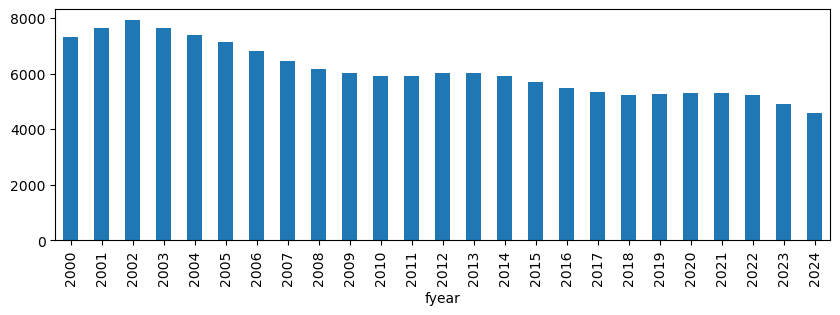

In [34]:
panel_clean["fyear"].value_counts().sort_index().plot(kind='bar', figsize=(10,3)) #No obvious fault line

In [35]:
desc = panel_clean[core_cols].describe(percentiles=[.1,.25,.5,.75,.9]).T
desc["missing%"] = panel_clean[core_cols].isna().mean().round(3)*100
desc

,count,mean,std,min,10%,25%,50%,75%,90%,max,missing%
book_leverage,152621.0,0.427483,1.131412,0.0,0.0,0.03319,0.195788,0.418944,0.710743,9.640464,0.0
log_assets,152621.0,5.60731,2.950276,-3.381395,1.728642,3.826835,5.97091,7.641336,9.071285,11.665055,0.0
roa,152621.0,-0.508705,2.388399,-19.710256,-0.76395,-0.135821,0.008381,0.048297,0.105946,0.439467,0.0
asset_tangibility,152621.0,0.214141,0.250573,0.000768,0.009804,0.023106,0.102665,0.321499,0.655706,0.914323,0.0
cash_holdings,152621.0,0.212429,0.261484,0.000405,0.009005,0.028732,0.092547,0.298359,0.656609,0.987398,0.0
non_debt_tax_shield,152621.0,0.063191,2.570723,-0.010186,0.001705,0.008843,0.028108,0.049772,0.08341,706.0,0.0


# Fit the variables 
to explore the relationship between the variables and LEV (capital structure)
The classic empirical framework of capital structure (such as Rajan & Zingales, 1995; Frank & Goyal, 2009) focuses on core determinants rather than "all possible accounting ratios".
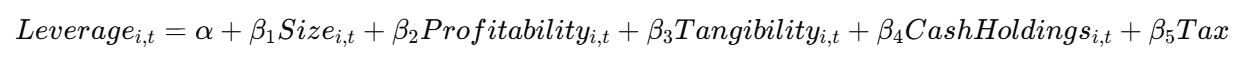

In [36]:
!pip install linearmodels --upgrade

In [39]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# panel_clean = panel_clean.set_index(["gvkey","fyear"])

# Baseline
X1 = panel_clean[["log_assets","roa","asset_tangibility","cash_holdings","non_debt_tax_shield"]]
y = panel_clean["book_leverage"]
X1 = sm.add_constant(X1)
model1 = PanelOLS(y, X1, entity_effects=True, time_effects=True)
res1 = model1.fit(cov_type="clustered", cluster_entity=True)

print("\n---Model A: Baseline Accounting Determinants of Capital Structure ---\n")
print(res1.summary)


---Model A: Baseline Accounting Determinants of Capital Structure ---

                          PanelOLS Estimation Summary                           
Dep. Variable:          book_leverage   R-squared:                        0.2968
Estimator:                   PanelOLS   R-squared (Between):              0.4000
No. Observations:              152621   R-squared (Within):               0.2811
Date:                Wed, Oct 22 2025   R-squared (Overall):              0.3097
Time:                        23:40:27   Log-likelihood                -1.508e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.174e+04
Entities:                       13549   P-value                           0.0000
Avg Obs:                       11.264   Distribution:                F(5,139043)
Min Obs:                       1.0000                                           
Max Obs:                       25.000

## Summary

| Variable                | Coefficient | Significance  | Interpretation                                                                                                                                                                                                                               |
| ----------------------- | ----------- | ------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **log_assets**          | -0.1750     | *** (p<0.001) | Larger firms have **lower book leverage**. Despite trade-off theory expecting a positive relation, this negative sign suggests that larger firms rely more on internal funds and equity markets, consistent with **pecking order behavior**. |
| **roa**                 | -0.2132     | ***           | Higher profitability reduces leverage, as profitable firms generate internal cash flow and need less external debt. This matches both **pecking order theory** and **free cash flow discipline view**.                                       |
| **asset_tangibility**   | +0.2202     | **            | Tangible assets increase leverage, as they serve as **collateral** that lowers the expected cost of financial distress. This supports **trade-off theory**.                                                                                  |
| **cash_holdings**       | -0.3359     | ***           | Firms with high cash reserves are less dependent on debt financing. This again supports **pecking order theory**.                                                                                                                            |
| **non_debt_tax_shield** | +0.0108     | ***           | Positive but small effect; suggests firms with more depreciation deductions may still maintain debt for tax optimization.                                                                                                                    |

Firm-level accounting factors behave consistently with classical theory. Leverage decreases with firm size, profitability, and liquidity, while it increases with collateralizable assets and tax shields. The overall fit (R²≈0.30) indicates these internal features are strong predictors of capital structure.